# RQ1: Functional vs Geometric Graph Evidence

## Research Question
Do functional graphs (DE/DC) outperform geometric SD for station-level 1-hour forecasting?

## Hypothesis
H1: At least one functional configuration (DE, DC, or DE+DC) yields lower test WMAPE than SD.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.notebook_reporting import canon_graph_set, optional_csv, relative_change, require_csv

ARTIFACT_ROOT = PROJECT_ROOT / 'data' / 'artifacts' / 'experiments'
sns.set_theme(style='whitegrid', context='talk')

In [2]:
rq_results = require_csv('rq_runner/results.csv', required_columns=('rq', 'aggregation', 'graph_set', 'model', 'test_wmape'))
rq1_rows = rq_results.filter((pl.col('rq') == 'RQ1') & (pl.col('aggregation') == 'station') & (pl.col('model') == 'graph_propagation')).to_pandas()
rq1_rows['graph_set'] = rq1_rows['graph_set'].apply(canon_graph_set)

rq_meta_path = ARTIFACT_ROOT / 'rq_runner' / 'metadata.json'
train_eval_meta_path = ARTIFACT_ROOT / 'train_eval_1h' / 'metadata.json'

provenance = pd.DataFrame([
    {'artifact': 'rq_runner/results.csv', 'exists': (ARTIFACT_ROOT / 'rq_runner' / 'results.csv').exists()},
    {'artifact': 'rq_runner/metadata.json', 'exists': rq_meta_path.exists()},
    {'artifact': 'train_eval_1h/station_robustness_statistics.csv', 'exists': (ARTIFACT_ROOT / 'train_eval_1h' / 'station_robustness_statistics.csv').exists()},
    {'artifact': 'train_eval_1h/metadata.json', 'exists': train_eval_meta_path.exists()},
])

inclusion = pd.DataFrame([
    {'criterion': 'RQ1 rows available', 'value': int(len(rq1_rows))},
    {'criterion': 'Unique graph sets', 'value': int(rq1_rows['graph_set'].nunique())},
    {'criterion': 'Any missing test_wmape', 'value': bool(rq1_rows['test_wmape'].isna().any())},
])

provenance, inclusion

(                                          artifact  exists
 0                            rq_runner/results.csv    True
 1                          rq_runner/metadata.json    True
 2  train_eval_1h/station_robustness_statistics.csv    True
 3                      train_eval_1h/metadata.json    True,
                 criterion  value
 0      RQ1 rows available      4
 1       Unique graph sets      4
 2  Any missing test_wmape  False)

In [3]:
rq1_summary = rq1_rows.groupby('graph_set', as_index=False)['test_wmape'].mean().sort_values('test_wmape')
baseline = dict(zip(rq1_summary['graph_set'], rq1_summary['test_wmape']))
sd = baseline.get('SD')

effect_rows = []
for candidate in ('DE', 'DC', 'DE+DC'):
    value = baseline.get(candidate)
    if value is None or sd is None:
        continue
    effect_rows.append({
        'comparison': f'{candidate} vs SD',
        'candidate_test_wmape': value,
        'sd_test_wmape': sd,
        'absolute_delta': value - sd,
        'relative_delta': relative_change(value, sd),
    })

rq1_effects = pd.DataFrame(effect_rows).sort_values('absolute_delta')
rq1_summary, rq1_effects

(  graph_set  test_wmape
 1        DE    0.785729
 2     DE+DC    0.801993
 3        SD    0.816169
 0        DC    0.840956,
     comparison  candidate_test_wmape  sd_test_wmape  absolute_delta  \
 0     DE vs SD              0.785729       0.816169       -0.030440   
 2  DE+DC vs SD              0.801993       0.816169       -0.014176   
 1     DC vs SD              0.840956       0.816169        0.024787   
 
    relative_delta  
 0       -0.037296  
 2       -0.017369  
 1        0.030370  )

In [4]:
robustness = optional_csv('train_eval_1h/station_robustness_statistics.csv', required_columns=('cohort', 'model', 'reference_model', 'test_station_wmape_mean', 'test_station_wmape_ci_lower', 'test_station_wmape_ci_upper', 'paired_sign_permutation_pvalue'))

if robustness is None:
    print('Uncertainty artifact unavailable: train_eval_1h/station_robustness_statistics.csv')
    rq1_uncertainty = pd.DataFrame()
else:
    rq1_uncertainty = robustness.filter((pl.col('model') == 'graph_propagation')).select([
        'cohort',
        'test_station_wmape_mean',
        'test_station_wmape_ci_lower',
        'test_station_wmape_ci_upper',
        'paired_sign_permutation_pvalue',
    ]).sort('cohort').to_pandas()

rq1_uncertainty

,cohort,test_station_wmape_mean,test_station_wmape_ci_lower,test_station_wmape_ci_upper,paired_sign_permutation_pvalue
0,all,1.205317,1.149018,1.253113,1.0
1,dense,1.061031,1.009789,1.101996,1.0
2,espoo,1.481227,1.398550,1.563132,1.0
3,helsinki,1.122463,1.069495,1.184084,1.0
4,sparse,1.635598,1.529213,1.750460,1.0
5,sparse_espoo,2.159819,2.040281,2.297155,1.0
6,sparse_helsinki,1.605925,1.494352,1.722374,1.0


In [5]:
sensitivity = optional_csv('train_eval_1h/sensitivity_summary.csv', required_columns=('sensitivity_axis', 'scope', 'aggregation', 'model', 'setting', 'metric', 'delta_vs_reference'))

if sensitivity is None:
    print('Sensitivity artifact unavailable: train_eval_1h/sensitivity_summary.csv')
    rq1_sensitivity = pd.DataFrame()
else:
    rq1_sensitivity = sensitivity.filter((pl.col('model') == 'graph_propagation') & (pl.col('sensitivity_axis').is_in(['hyperparameter', 'resolution']))).sort(['scope', 'setting']).to_pandas()

rq1_sensitivity.head(20)

,sensitivity_axis,scope,aggregation,model,setting,metric,value,reference_value,delta_vs_reference
0,hyperparameter,graph_propagation_alpha,station,graph_propagation,alpha=0.1,validation_wmape,0.839668,0.808920,0.030748
1,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.1,validation_wmape,0.308655,0.278413,0.030242
2,hyperparameter,graph_propagation_alpha,community,graph_propagation,alpha=0.5,validation_wmape,0.278413,0.278413,0.000000
3,hyperparameter,graph_propagation_alpha,station,graph_propagation,alpha=0.5,validation_wmape,0.808920,0.808920,0.000000
4,resolution,station_vs_community,station_community,graph_propagation,aggregation_resolution,test_wmape,0.804808,0.293584,0.511224


C:\Users\stefa\AppData\Local\Temp\ipykernel_14332\330308528.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=rq1_summary, x='graph_set', y='test_wmape', palette='viridis')


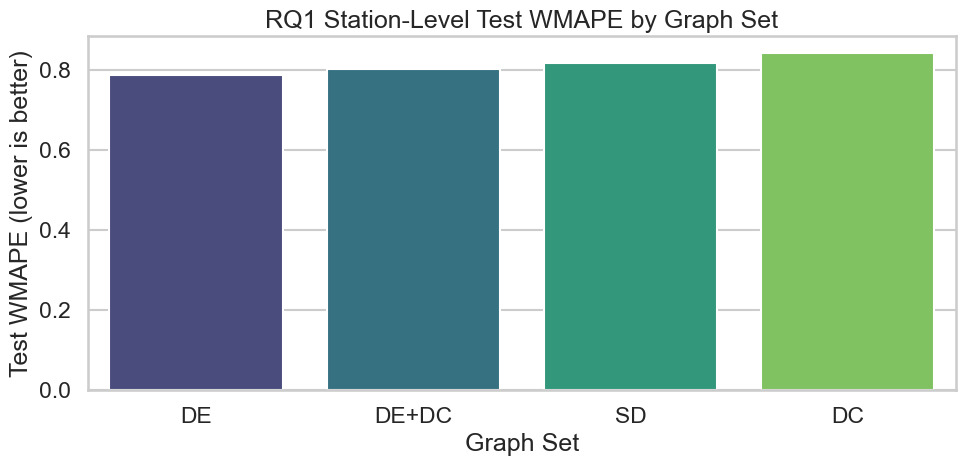

In [6]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=rq1_summary, x='graph_set', y='test_wmape', palette='viridis')
ax.set_title('RQ1 Station-Level Test WMAPE by Graph Set')
ax.set_xlabel('Graph Set')
ax.set_ylabel('Test WMAPE (lower is better)')
plt.tight_layout()
plt.show()

## Threats To Validity (RQ1)

- RQ1 compares graph families but not all possible model classes; conclusions are conditional on graph_propagation baselines.
- Robustness p-values are model-vs-reference summaries from train_eval and are not direct between-graph-set tests.
- External validity remains bounded by Helsinki-Espoo split and demand dynamics.

In [7]:
best_functional = rq1_summary[rq1_summary['graph_set'].isin(['DE', 'DC', 'DE+DC'])]['test_wmape'].min() if not rq1_summary.empty else np.nan
sd_value = rq1_summary.loc[rq1_summary['graph_set'] == 'SD', 'test_wmape'].min() if not rq1_summary.empty else np.nan

if np.isfinite(best_functional) and np.isfinite(sd_value):
    delta = best_functional - sd_value
    status = 'supported' if delta < 0 else 'mixed_or_not_supported'
    rationale = f'Best functional minus SD test_wmape = {delta:.6f}'
else:
    status = 'insufficient_data'
    rationale = 'Missing SD or functional rows in artifact tables.'

pd.DataFrame([{'rq': 'RQ1', 'claim_status': status, 'rationale': rationale}])

,rq,claim_status,rationale
0,RQ1,supported,Best functional minus SD test_wmape = -0.030440
